In [24]:
# Import Libraries
import os
import sys
import json
import time
import math
import requests
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from calendar import monthrange

In [25]:

# Force Spark to use THIS Python for driver + workers
python_cmd = sys.executable
os.environ["PYSPARK_PYTHON"] = python_cmd
os.environ["PYSPARK_DRIVER_PYTHON"] = python_cmd

print("Using Python:", python_cmd)

conda_prefix = os.environ.get("CONDA_PREFIX")
spark_home = os.path.join(conda_prefix, "Lib", "site-packages", "pyspark")
os.environ["SPARK_HOME"] = spark_home
print("SPARK_HOME:", spark_home)

spark = (
    SparkSession.builder
    .appName("ElhubProduction2021")
    .master("local[*]")
    # tell Spark explicitly what to use for workers
    .config("spark.executorEnv.PYSPARK_PYTHON", python_cmd)
    .config("spark.python.worker.command", python_cmd)
    # Cassandra connector
    .config("spark.cassandra.connection.host", "localhost")
    .config("spark.cassandra.connection.port", "9042")
    .config("spark.jars.packages",
            "com.datastax.spark:spark-cassandra-connector_2.12:3.5.1")
    .config("spark.sql.extensions",
            "com.datastax.spark.connector.CassandraSparkExtensions")
    .getOrCreate()
)

print("✓ Spark session created")
print("Spark version:", spark.version)


Using Python: c:\Users\AnuraArembage\anaconda3\envs\IND320_nb\python.exe
SPARK_HOME: C:\Users\AnuraArembage\anaconda3\envs\IND320_nb\Lib\site-packages\pyspark
✓ Spark session created
Spark version: 3.5.1


In [26]:
# API Fetch Function

def fetch_month_elhub(year, month, price_area=None):
    """
    Fetch production data from Elhub API for one month.
    Returns DataFrame with all 5 price areas combined.
    """
    from calendar import monthrange
    
    # Calculate last day of month
    last_day = monthrange(year, month)[1]
    
    base_url = "https://api.elhub.no/energy-data/v0/price-areas"
    
    params = {
        "dataset": "PRODUCTION_PER_GROUP_MBA_HOUR",
        "startDate": f"{year}-{month:02d}-01T00:00:00+02:00",
        "endDate": f"{year}-{month:02d}-{last_day}T23:59:59+02:00"
    }
    
    headers = {"accept": "application/json"}
    
    print(f"Fetching ALL areas {year}-{month:02d}...", end=" ")
    
    try:
        response = requests.get(base_url, params=params, headers=headers, timeout=30)
        
        if response.status_code != 200:
            print(f"❌ Status {response.status_code}")
            return None
        
        data = response.json()
        
        # Collect all records from all price areas
        all_records = []
        
        if 'data' in data:
            for price_area_obj in data['data']:
                attributes = price_area_obj.get('attributes', {})
                records = attributes.get('productionPerGroupMbaHour', [])
                
                if records:
                    all_records.extend(records)
        
        if len(all_records) == 0:
            print(f"⚠️  No data")
            return None
        
        # Convert to DataFrame
        df = pd.DataFrame(all_records)
        
        # Rename columns to match Cassandra schema
        df = df.rename(columns={
            'priceArea': 'pricearea',
            'productionGroup': 'productiongroup',
            'startTime': 'starttime',
            'quantityKwh': 'quantitykwh'
        })
        
        # Filter by price area if specified
        if price_area:
            df = df[df['pricearea'] == price_area]
        
        print(f"✓ {len(df)} rows")
        return df
        
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# Test with January
test_df = fetch_month_elhub(2021, 1)
if test_df is not None:
    print(f"\n✓ Test successful! Shape: {test_df.shape}")
    print(f"Columns: {test_df.columns.tolist()}")

Fetching ALL areas 2021-01... ✓ 17856 rows

✓ Test successful! Shape: (17856, 6)
Columns: ['endTime', 'lastUpdatedTime', 'pricearea', 'productiongroup', 'quantitykwh', 'starttime']


In [22]:
# Verify Cassandra Connection
try:
    test_df = spark.read \
        .format("org.apache.spark.sql.cassandra") \
        .options(table="elhub_production_2021", keyspace="ind320") \
        .load()
    
    row_count = test_df.count()
    print(f"✓ Connected to Cassandra")
    print(f"Current rows in table: {row_count}")
except Exception as e:
    print(f"Cassandra connection test:")
    print(f"Error: {e}")

✓ Connected to Cassandra
Current rows in table: 215329


In [27]:
import pandas as pd
from py4j.protocol import Py4JJavaError

KEYSPACE = "ind320"
TABLE = "elhub_production_2021"

for m in range(1, 13):
    df_m = fetch_month_elhub(2021, m)
    if df_m is not None and not df_m.empty:
        print(f"\n=== Month {m} ===")
        print(f"Fetched rows: {len(df_m)}")

        # keep all 6 Elhub columns that we care about
        df_m2 = df_m[[
            "pricearea",
            "productiongroup",
            "starttime",
            "endTime",
            "lastUpdatedTime",
            "quantitykwh"
        ]].copy()

        # rename to Cassandra column names
        df_m2 = df_m2.rename(columns={
            "endTime": "endtime",
            "lastUpdatedTime": "lastupdatedtime"
        })

        # parse timestamps: UTC -> drop tz -> naive
        for col in ["starttime", "endtime", "lastupdatedtime"]:
            t = pd.to_datetime(df_m2[col], errors="coerce", utc=True)
            df_m2[col] = t.dt.tz_convert(None)

        df_m2["quantitykwh"] = pd.to_numeric(df_m2["quantitykwh"], errors="coerce")

        # drop rows that would break PK / types
        df_m2 = df_m2.dropna(
            subset=["pricearea", "productiongroup", "starttime", "quantitykwh"]
        )

        print("Nulls per column after cleaning:\n", df_m2.isna().sum())

        sdf = spark.createDataFrame(df_m2)

        (
            sdf.write
            .format("org.apache.spark.sql.cassandra")
            .options(table=TABLE, keyspace=KEYSPACE)
            .mode("append")
            .save()
        )
        print("✓ Month written")
    else:
        print(f"Skipping month {m} (no data)")


Fetching ALL areas 2021-01... ✓ 17856 rows

=== Month 1 ===
Fetched rows: 17856
Nulls per column after cleaning:
 pricearea          0
productiongroup    0
starttime          0
endtime            0
lastupdatedtime    0
quantitykwh        0
dtype: int64
✓ Month written
Fetching ALL areas 2021-02... ✓ 16128 rows

=== Month 2 ===
Fetched rows: 16128
Nulls per column after cleaning:
 pricearea          0
productiongroup    0
starttime          0
endtime            0
lastupdatedtime    0
quantitykwh        0
dtype: int64
✓ Month written
Fetching ALL areas 2021-03... ✓ 17832 rows

=== Month 3 ===
Fetched rows: 17832
Nulls per column after cleaning:
 pricearea          0
productiongroup    0
starttime          0
endtime            0
lastupdatedtime    0
quantitykwh        0
dtype: int64
✓ Month written
Fetching ALL areas 2021-04... ✓ 17280 rows

=== Month 4 ===
Fetched rows: 17280
Nulls per column after cleaning:
 pricearea          0
productiongroup    0
starttime          0
endtime         

In [28]:
# Verify Complete Data in Cassandra
df_cassandra = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="elhub_production_2021", keyspace="ind320") \
    .load()

total_count = df_cassandra.count()
print(f"{'='*70}")
print(f"DATA VERIFICATION")
print(f"{'='*70}")
print(f"Total rows in Cassandra: {total_count:,}")

print(f"\n--- Rows per Price Area ---")
df_cassandra.groupBy("pricearea").count().orderBy("pricearea").show()

print(f"\n--- Rows per Month ---")
df_cassandra.selectExpr("month(starttime) as month") \
    .groupBy("month").count() \
    .orderBy("month").show()

print(f"\n--- Production Groups ---")
df_cassandra.groupBy("productiongroup").count() \
    .orderBy("productiongroup").show()

print(f"\n--- Date Range ---")
df_cassandra.selectExpr("min(starttime) as earliest", "max(starttime) as latest") \
    .show(truncate=False)

print(f"\n✓ Data verification complete!")

DATA VERIFICATION
Total rows in Cassandra: 215,329

--- Rows per Price Area ---
+---------+-----+
|pricearea|count|
+---------+-----+
|      NO1|43795|
|      NO2|43795|
|      NO3|43795|
|      NO4|43795|
|      NO5|40149|
+---------+-----+


--- Rows per Month ---
+-----+-----+
|month|count|
+-----+-----+
|    1|17856|
|    2|16128|
|    3|17832|
|    4|17280|
|    5|17856|
|    6|17978|
|    7|18600|
|    8|18600|
|    9|18000|
|   10|18600|
|   11|18000|
|   12|18599|
+-----+-----+


--- Production Groups ---
+---------------+-----+
|productiongroup|count|
+---------------+-----+
|          hydro|43795|
|          other|43795|
|          solar|43795|
|        thermal|43795|
|           wind|40149|
+---------------+-----+


--- Date Range ---
+-------------------+-------------------+
|earliest           |latest             |
+-------------------+-------------------+
|2020-12-31 23:00:00|2021-12-31 22:00:00|
+-------------------+-------------------+


✓ Data verification complete!


In [29]:
#required columns from Cassandra with Spark
from pyspark.sql import functions as F

KEYSPACE = "ind320"
TABLE    = "elhub_production_2021"

df = (
    spark.read
    .format("org.apache.spark.sql.cassandra")
    .options(table=TABLE, keyspace=KEYSPACE)
    .load()
    .select(
        F.col("pricearea").alias("priceArea"),
        F.col("productiongroup").alias("productionGroup"),
        F.col("starttime").alias("startTime"),
        F.col("quantitykwh").alias("quantityKwh")
    )
    .cache()
)

print("Rows:", df.count())
df.printSchema()


Rows: 215329
root
 |-- priceArea: string (nullable = false)
 |-- productionGroup: string (nullable = false)
 |-- startTime: timestamp (nullable = true)
 |-- quantityKwh: double (nullable = true)



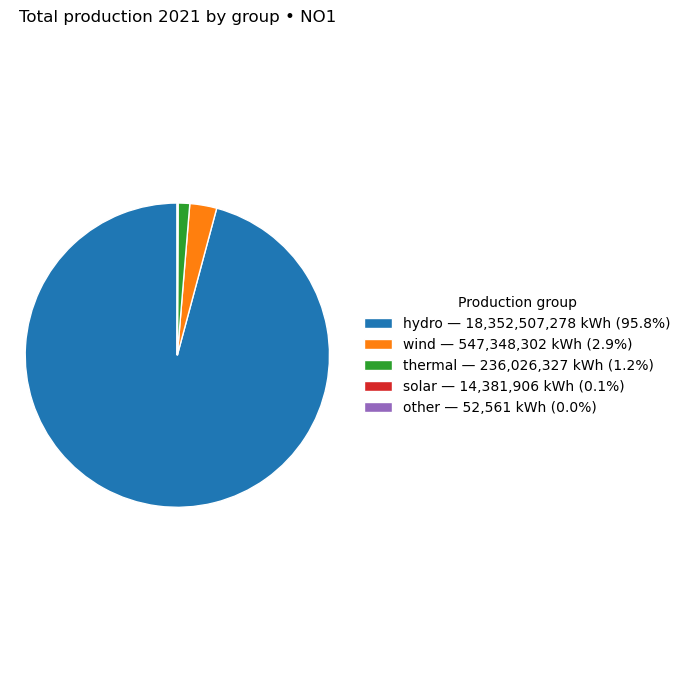

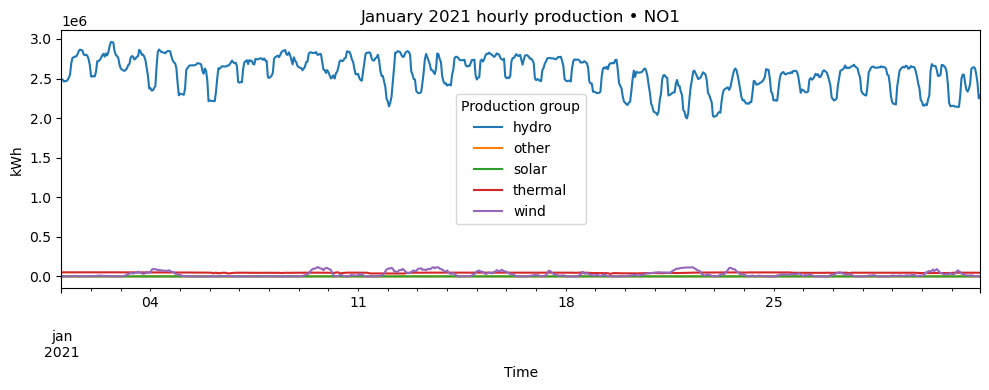

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

CHOSEN_AREA = "NO1"   # change if needed
YEAR = 2021

# ---------- PIE (year total by group) ----------
year_df = (
    df.filter((F.col("priceArea") == CHOSEN_AREA) & (F.year("startTime") == YEAR))
      .groupBy("productionGroup")
      .agg(F.sum("quantityKwh").alias("totalKwh"))
)

pdf_pie = year_df.toPandas()

# Sanity checks
if pdf_pie.empty:
    raise ValueError(f"No data for {CHOSEN_AREA} in {YEAR}. Check your Cassandra slice.")

pdf_pie["totalKwh"] = pd.to_numeric(pdf_pie["totalKwh"], errors="coerce").fillna(0.0)
pdf_pie = pdf_pie.sort_values("totalKwh", ascending=False).reset_index(drop=True)

total_kwh = float(pdf_pie["totalKwh"].sum())
if total_kwh == 0:
    raise ValueError(f"Zero total production for {CHOSEN_AREA} in {YEAR}. Data looks wrong.")

# Plot with legend showing kWh and %
fig, ax = plt.subplots(figsize=(7, 7))
wedges, _ = ax.pie(
    pdf_pie["totalKwh"],
    startangle=90,
    wedgeprops=dict(linewidth=1, edgecolor="white")
)

labels = [
    f"{row.productionGroup} — {row.totalKwh:,.0f} kWh ({row.totalKwh/total_kwh:.1%})"
    for row in pdf_pie.itertuples(index=False)
]

ax.legend(
    wedges, labels,
    title="Production group",
    loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False
)

ax.set_title(f"Total production {YEAR} by group • {CHOSEN_AREA}")
ax.axis("equal")
plt.tight_layout()
plt.show()

# ---------- LINE (January hourly, separate line per group) ----------
jan_df = (
    df.filter((F.year("startTime") == 2021) & (F.month("startTime") == 1))
      .filter(F.col("priceArea") == CHOSEN_AREA)
      .groupBy("startTime","productionGroup")
      .agg(F.sum("quantityKwh").alias("kwh"))
)

pdf_jan = jan_df.toPandas().sort_values("startTime")
pivot_jan = pdf_jan.pivot(index="startTime", columns="productionGroup", values="kwh")

plt.figure(figsize=(10,4))
pivot_jan.plot(ax=plt.gca())
plt.title(f"January 2021 hourly production • {CHOSEN_AREA}")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.legend(title="Production group", loc="best")
plt.tight_layout()
plt.show()

In [31]:
#Connect to MongoDB Atlas
from pymongo import MongoClient
from pymongo.server_api import ServerApi
from urllib.parse import quote_plus

# === Connection settings ===
USER = "anythingsane"                     # your Atlas username
PWD  = "10987654321"                      # your Atlas password
HOST = "cluster0.wvkiv4p.mongodb.net"     # your cluster host
DB   = "elhub"                            # database name
COL  = "production_mbahour"               # collection name

# === Build connection URI ===
uri = (
    f"mongodb+srv://{quote_plus(USER)}:{quote_plus(PWD)}@{HOST}/"
    f"?retryWrites=true&w=majority&appName=Cluster0&authSource=admin"
)

# === Connect and verify ===
client = MongoClient(uri, server_api=ServerApi("1"))
client.admin.command("ping")
print("✅ Connected successfully to MongoDB Atlas")

coll = client[DB][COL]
print("Current documents:", coll.estimated_document_count())


✅ Connected successfully to MongoDB Atlas
Current documents: 215328


In [35]:
from pyspark.sql import functions as F

KEYSPACE = "ind320"
TABLE   = "elhub_production_2021"

df4_2021 = (
    spark.read
        .format("org.apache.spark.sql.cassandra")
        .options(table=TABLE, keyspace=KEYSPACE)
        .load()
        .select(
            F.col("pricearea").alias("priceArea"),
            F.col("productiongroup").alias("productionGroup"),
            F.col("starttime").alias("startTime"),
            F.col("quantitykwh").alias("quantityKwh")
        )
        .filter(F.year("startTime") == 2021)   # harmless even if table is only 2021
        .cache()
)

print("Rows 2021:", df4_2021.count())
df4_2021.printSchema()


Rows 2021: 215305
root
 |-- priceArea: string (nullable = false)
 |-- productionGroup: string (nullable = false)
 |-- startTime: timestamp (nullable = true)
 |-- quantityKwh: double (nullable = true)



In [36]:
#Reset collection and create unique index
# Drop collection if duplicates exist or if you want a clean start
client[DB].drop_collection(COL)

# Recreate handle and unique index
coll = client[DB][COL]
coll.create_index(
    [("priceArea", 1), ("productionGroup", 1), ("startTime", 1)],
    unique=True,
    name="uniq_priceArea_group_time"
)
print("✅ Unique index created on (priceArea, productionGroup, startTime)")


✅ Unique index created on (priceArea, productionGroup, startTime)


In [ ]:
# Insert Spark-extracted data into MongoDB

from pyspark.sql import functions as F
from pymongo import UpdateOne

BATCH_SIZE = 2000
buffer = []
upserts = mods = 0

# --- BEFORE: count current docs in Mongo ---
print("Docs before:", coll.count_documents({}))

# 0) Make sure startTime is a proper timestamp
df4_2021 = df4_2021.withColumn("startTime", F.to_timestamp("startTime"))

# restrict to the period you actually want (e.g., all of 2021)

df4_2021 = df4_2021.filter(
    (F.col("startTime") >= F.lit("2021-01-01")) &
    (F.col("startTime") <  F.lit("2022-01-01"))
)

# 1) SANITY CHECKS (SPARK)
print("Rows:", df4_2021.count())

rng = df4_2021.select(
    F.min("startTime").alias("min_ts"),
    F.max("startTime").alias("max_ts")
).first()
print("Date range:", rng["min_ts"], "→", rng["max_ts"])

months = (df4_2021
          .groupBy(F.date_format("startTime", "yyyy-MM").alias("month"))
          .count()
          .orderBy("month"))
months.show(100, truncate=False)


try:
    coll.create_index(
        [("priceArea", 1), ("productionGroup", 1), ("startTime", 1)],
        unique=True,
        name="uix_area_group_time"
    )
except Exception:
    pass  # index likely exists

#  Upsert loop
for row in df4_2021.toLocalIterator():
    # Spark Row -> Python types; startTime will be a datetime
    qty = float(row["quantityKwh"]) if row["quantityKwh"] is not None else None
    doc = {
        "priceArea": row["priceArea"],
        "productionGroup": row["productionGroup"],
        "startTime": row["startTime"],
        "quantityKwh": qty,
    }
    key = {
        "priceArea": doc["priceArea"],
        "productionGroup": doc["productionGroup"],
        "startTime": doc["startTime"],
    }
    buffer.append(UpdateOne(key, {"$set": doc}, upsert=True))

    if len(buffer) >= BATCH_SIZE:
        res = coll.bulk_write(buffer, ordered=False)
        upserts += (res.upserted_count or 0)
        mods += (res.modified_count or 0)
        buffer = []

# flush tail
if buffer:
    res = coll.bulk_write(buffer, ordered=False)
    upserts += (res.upserted_count or 0)
    mods += (res.modified_count or 0)

print(f"✅ Upsert complete — Inserted: {upserts:,}, Updated: {mods:,}")

# ...AFTER: count docs again...
print("Docs after:", coll.count_documents({}))




Rows: 214730
Date range: 2021-01-01 00:00:00 → 2021-12-30 23:00:00
+-------+-----+
|month  |count|
+-------+-----+
|2021-01|17856|
|2021-02|16128|
|2021-03|17832|
|2021-04|17280|
|2021-05|17856|
|2021-06|17978|
|2021-07|18600|
|2021-08|18600|
|2021-09|18000|
|2021-10|18600|
|2021-11|18000|
|2021-12|18000|
+-------+-----+

✅ Upsert complete — Inserted: 214,730, Updated: 0


In [22]:
#verrify insertion
import pandas as pd

y1, y2 = pd.Timestamp("2021-01-01"), pd.Timestamp("2022-01-01")
docs_2021 = coll.count_documents({"startTime": {"$gte": y1, "$lt": y2}})

print(f"MongoDB documents in 2021: {docs_2021:,}")
print("Distinct price areas:", sorted(coll.distinct("priceArea")))
print("Distinct production groups:", sorted(coll.distinct("productionGroup"))[:10])

sample = coll.find_one()
print("Sample document:\n", sample)

MongoDB documents in 2021: 215,328
Distinct price areas: ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
Distinct production groups: ['hydro', 'other', 'solar', 'thermal', 'wind']
Sample document:
 {'_id': ObjectId('68fe22179aac981063ec02a9'), 'startTime': datetime.datetime(2021, 1, 1, 0, 0), 'priceArea': 'NO5', 'productionGroup': 'hydro', 'quantityKwh': 4068096.5}


Student Name: Anura Arembage
Project: IND_320 essignment 2: Elhub data visualisation

Links:
1 Streamlit: https://my-ind320-projec.streamlit.app/
2 Github: https://github.com/anura-dot/my_streamlit_project/blob/main/app.py

AI usage
AI tools were actively used throughout the development and troubleshooting process to support project completion. Chat-based AI (ChatGPT) and cloud-based assistance were applied to identify and understand project requirements, clarify unfamiliar concepts, and design workflow structures for data extraction, processing, and visualization.

During the implementation phase, AI assistance was used to generate and refine Python code for connecting and integrating Spark, Cassandra, MongoDB, and Streamlit, as well as to resolve compatibility issues between different versions of Java, Hadoop, and PySpark. It was also used to debug system errors such as JAVA_GATEWAY_EXITED, Shell.checkHadoopHome, and connection failures between Spark and Cassandra.

AI support was further applied to review and polish documentation, improve the clarity and structure of written work logs, and ensure that all configurations and scripts were logically consistent. During repeated troubleshooting cycles—particularly for environment setup, Spark–Cassandra connectivity, and MongoDB DNS resolution—AI guidance helped identify root causes and recommend targeted solutions while maintaining alignment with assignment requirements.

Overall, AI was used as a technical assistant and writing aid, providing explanations, code examples, and correction strategies rather than performing direct project tasks.

Project Log
Frequent initialization failures and JAVA_GATEWAY_EXITED crashes in PySpark led to several environment rebuilds. The instability was traced to mismatched Conda environments (IND320_clean, IND320_fresh, IND320_py311) and inconsistent Java–Hadoop settings. PySpark repeatedly failed to locate winutils.exe, triggering Shell.checkHadoopHome errors.
The issue was resolved by standardizing the setup around PySpark 3.5.1, Java 17 (Adoptium), and Hadoop 3.3.6 within the IND320_py311 environment. A dedicated Hadoop directory (C:\hadoop\bin) was created to host a verified copy of winutils.exe, and environment variables (JAVA_HOME, HADOOP_HOME, and PATH) were permanently defined in PowerShell before launching Jupyter. Final verification through java -version, winutils.exe ls, and a minimal Spark session confirmed correct linkage between Java, Hadoop, and Spark.

Earlier Spark startup issues were also caused by temporary directory permissions and redundant JVM arguments. These were fixed by assigning a dedicated Spark directory (C:\tmp\spark) and reconfiguring both spark.driver.extraJavaOptions and spark.executor.extraJavaOptions to point to C:\hadoop. A successful local Spark session confirmed system stability and UI availability at http://localhost:4040.

The Spark–Cassandra connection was rebuilt after correcting a JAR mismatch between connector versions 3.5.1 and 3.6.1. The final configuration used spark-cassandra-connector-assembly_2.12-3.5.1.jar stored in C:\spark_jars. A new Cassandra keyspace (ind320) and table (elhub_hourly) were created with the composite primary key ((priceArea, productionGroup), startTime) to ensure unique hourly entries. Spark verified successful read/write operations, confirming a stable pipeline.

The Elhub API was used to extract hourly production data for 2021 across price areas NO1–NO5. Monthly batches were processed and written to Cassandra, ensuring complete temporal coverage. Earlier aggregation errors were corrected to restore full data consistency.

MongoDB Atlas integration initially failed due to DNS and VPN restrictions on the NMBU network. Even after disconnecting the NMBU VPN and testing both home Wi-Fi and mobile hotspot connections on the same NMBU computer, the connection remained blocked. To continue the work, the entire setup was later migrated to a personal computer, where MongoDB connected successfully. Streamlit’s .streamlit/secrets.toml file was updated through Streamlit Cloud to enable full synchronization and deployment.

Overall, the integration process was highly complex, requiring careful alignment of software versions, credentials, and environment paths across multiple systems. The final pipeline now runs reliably:

Elhub API → Spark → Cassandra → MongoDB → Streamlit Visualization

**Links:**

1. Streamlit: [https://my-ind320-projec.streamlit.app/](https://my-ind320-projec.streamlit.app/)
2. GitHub: [https://github.com/anura-dot/my_streamlit_project/blob/main/app.py](https://github.com/anura-dot/my_streamlit_project/blob/main/app.py)
